# import Toolkit

In [94]:
import numpy   as np
import pandas  as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from gensim.models            import Word2Vec
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow                  as tf
from tensorflow.keras.models       import Sequential
from tensorflow.keras.layers       import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks    import EarlyStopping
from tensorflow.keras.utils        import to_categorical

In [95]:
df_train = pd.read_csv('/content/train.txt', sep = ';', header = None, names = ["text", "label"], engine='python')
df_test  = pd.read_csv('/content/test.txt', sep = ';', header = None, names = ["text", "label"], engine='python')
df_val = pd.read_csv('/content/val.txt', sep = ';', header = None, names = ["text", "labe|l"], engine='python')

df = pd.concat([df_train, df_test], ignore_index=True ).reset_index(drop = True)
df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [96]:
df['label'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

<Axes: xlabel='label'>

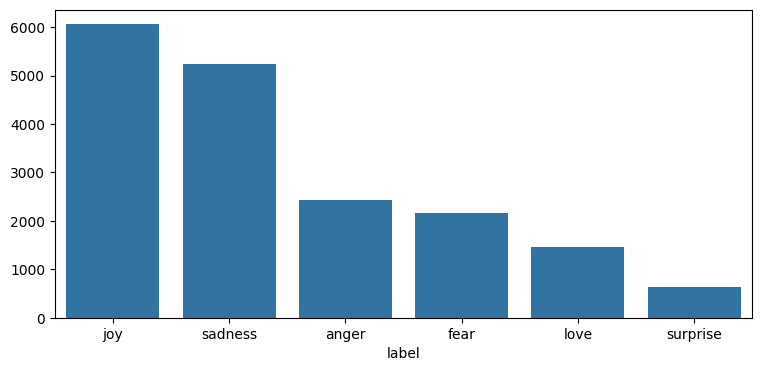

In [97]:
counts = df["label"].value_counts()
plt.figure(figsize=(9, 4))
sns.barplot(x=counts.index, y=counts.values)

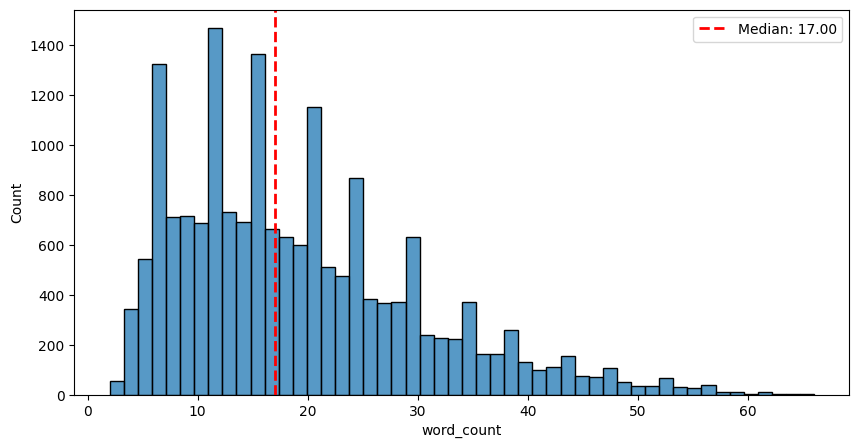

In [98]:
df ["word_count"] = df["text"].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df["word_count"], bins=50)
plt.axvline(df["word_count"].median(), color='red', linestyle='dashed', linewidth=2, label = f"Median: {df['word_count'].median():.2f}")
plt.legend()

In [99]:
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()
    tokens  = [ t for t in tokens if len(t)>1 ]
    return tokens



In [100]:
df["tokens"] = df["text"].apply(clean_and_tokenize)

print("Original :" , df["text"][0])
print("Tokens   :" , df["tokens"][0])

Original : i didnt feel humiliated
Tokens   : ['didnt', 'feel', 'humiliated']


In [101]:
from gensim.models.word2vec import Vocab
sentences = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg =1,
    epochs= 10,
    workers=4 ,
    seed = 42 )

Vocab_size  = len(w2v_model.wv)
print(f"vocabulary size : {Vocab_size:,} words")
print(f"Vector size     : {w2v_model.vector_size}")


vocabulary size : 7,913 words
Vector size     : 100


In [102]:
for word in ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']:
  if word in w2v_model.wv:
    similar = w2v_model.wv.most_similar(word, topn=5)
    print(f"\nMost similar to: '{word}':")
    for w, score in similar:
      print(f"{w:<20}: {score:.3f}")



Most similar to: 'sadness':
grief               : 0.806
confusion           : 0.804
anger               : 0.804
concern             : 0.799
sides               : 0.796

Most similar to: 'anger':
sadness             : 0.804
frustration         : 0.796
jealousy            : 0.790
embarrassment       : 0.779
resentment          : 0.776

Most similar to: 'love':
encourage           : 0.686
despised            : 0.658
wonders             : 0.655
creating            : 0.655
affects             : 0.654

Most similar to: 'surprise':
revealed            : 0.900
sleeps              : 0.900
adapt               : 0.898
larger              : 0.895
paused              : 0.894

Most similar to: 'fear':
grief               : 0.813
relief              : 0.799
dread               : 0.798
disdain             : 0.798
suppressed          : 0.793

Most similar to: 'joy':
blessing            : 0.789
friendship          : 0.785
enthusiasm          : 0.781
jesus               : 0.780
grief               : 0.7

In [103]:
def sentence_vector(tokens , model , vector_size=100 ):
  vectors = [model.wv[w] for w in tokens if w in model.wv]
  if len(vectors)== 0 :
    return np.zeros(vector_size)
  return np.mean(vectors , axis = 0 )

x = np.array([sentence_vector(toks, w2v_model) for toks in df["tokens"]])

print(f'Feature matrix shape: {x.shape}')
print(f'Each sentence -> vector of {x.shape[1]} numbers')

Feature matrix shape: (18000, 100)
Each sentence -> vector of 100 numbers


In [104]:
le = LabelEncoder()
y= le.fit_transform(df["label"])
num_classes = len(le.classes_)

for i , cls in enumerate(le.classes_):
  print(f"{i} : {cls}")


0 : anger
1 : fear
2 : joy
3 : love
4 : sadness
5 : surprise


In [105]:
x_train, x_test, ytrain, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y )
print(f'Train : {x_train.shape[0]} samples')
print(f'Test  : {x_test.shape[0]} samples')

Train : 14400 samples
Test  : 3600 samples


In [106]:
ml_results = {}

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "SVM (RBF Kernel)"    : SVC(kernel="rbf", C =1.0, probability=True, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

for model_name, model in models.items():
  print(f'\n{"-" * 55}')
  print(f' Training: {model_name}')
  print(f'{"-" * 55}')
  model.fit(x_train, ytrain)
  y_pred = model.predict(x_test)

  acc= accuracy_score(y_test, y_pred)
  f1= f1_score(y_test, y_pred, average='weighted')
  ml_results[model_name] = {"accuracy": acc, "f1_score": f1, "Model": model, "pred": y_pred}
  print(f'Accuracy: {acc:.4f}')
  print(f'F1 Score: {f1:.4f}\n')
  print(classification_report(y_test, y_pred, target_names=le.classes_))


-------------------------------------------------------
 Training: Logistic Regression
-------------------------------------------------------
Accuracy: 0.5069
F1 Score: 0.4515

              precision    recall  f1-score   support

       anger       0.36      0.13      0.19       487
        fear       0.44      0.18      0.25       432
         joy       0.57      0.80      0.67      1211
        love       0.31      0.07      0.11       293
     sadness       0.47      0.65      0.55      1049
    surprise       0.64      0.05      0.10       128

    accuracy                           0.51      3600
   macro avg       0.46      0.31      0.31      3600
weighted avg       0.48      0.51      0.45      3600


-------------------------------------------------------
 Training: SVM (RBF Kernel)
-------------------------------------------------------
Accuracy: 0.5022
F1 Score: 0.4071

              precision    recall  f1-score   support

       anger       0.48      0.02      0.04    

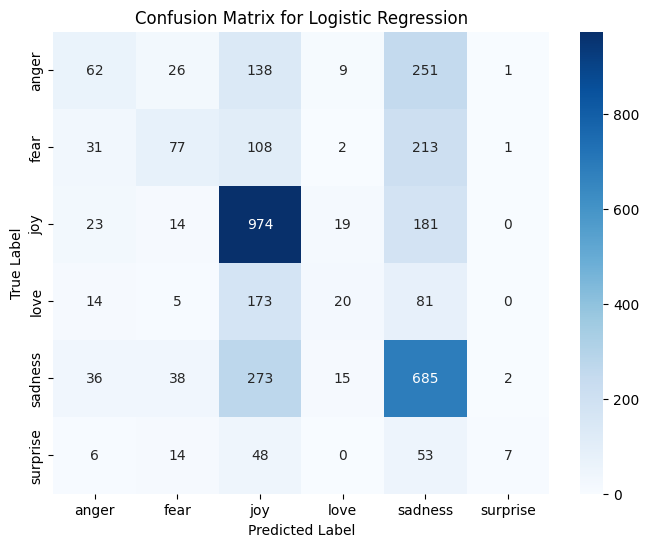

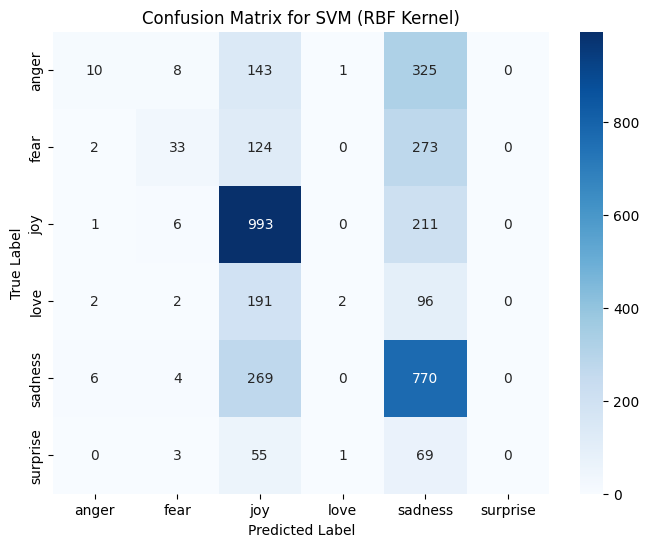

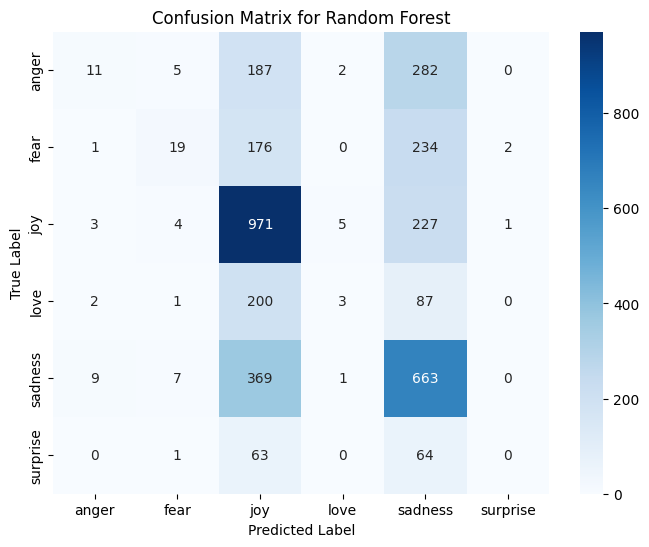

In [107]:

for model_name, result in ml_results.items():
    y_pred = result["pred"]
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [108]:
y_train_cat = to_categorical(ytrain, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

def create_model(input_shape, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_shape,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),

        Dense(num_classes, activation='softmax')

    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

nn_model= create_model(input_shape= 100 , num_classes= num_classes)
nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,934 (269.27 KB)

 Trainable params: 68,166 (266.27 KB)

 Non-trainable params: 768 (3.00 KB)

In [124]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    x_train, y_train_cat,
    validation_split   =0.2              ,
    epochs             =100              ,
    batch_size         =64               ,
    callbacks          =[early_stopping] ,
    verbose            = 1
)

print(f'\nTraining Stoped at epoch {early_stopping.stopped_epoch}')

Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6115 - loss: 1.0075 - val_accuracy: 0.5236 - val_loss: 1.2457
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6089 - loss: 1.0063 - val_accuracy: 0.5247 - val_loss: 1.2408
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6070 - loss: 1.0096 - val_accuracy: 0.5146 - val_loss: 1.2248
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6133 - loss: 0.9995 - val_accuracy: 0.5274 - val_loss: 1.2244
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6193 - loss: 0.9978 - val_accuracy: 0.5142 - val_loss: 1.2492
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6109 - loss: 1.0023 - val_accuracy: 0.5312 - val_loss: 1.2522
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6150 - loss: 0.9958 - val_accuracy: 0.5181 - val_loss: 1.2352
Epoch 8/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6156 - loss: 0.9931 - val_acc

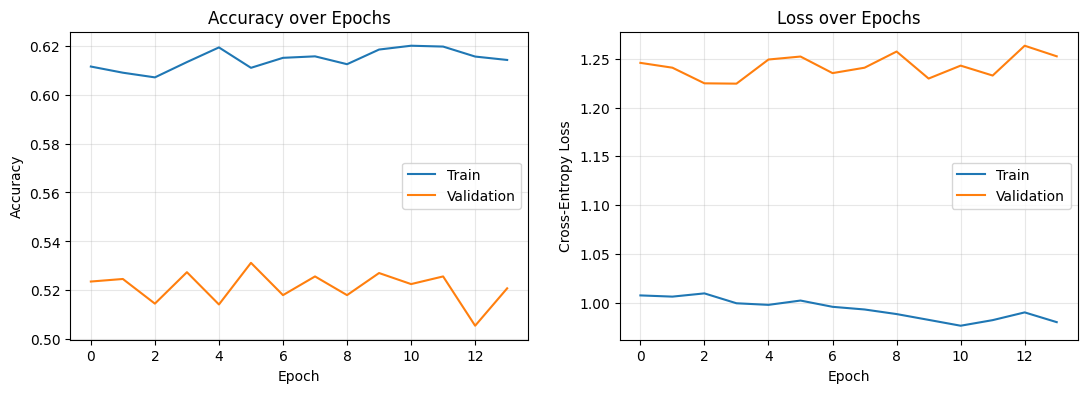

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

In [126]:

y_pred_prob = nn_model.predict(x_test, verbose=0)
y_pred_nn   = np.argmax(y_pred_prob, axis=1)

nn_acc = accuracy_score(y_test, y_pred_nn)
nn_f1  = f1_score(y_test, y_pred_nn, average='weighted')

print(f'Neural Network - Test Accuracy : {nn_acc:.4f}')
print(f'Neural Network - Weighted F1  : {nn_f1:.4f}')
print()

print(classification_report(y_test, y_pred_nn, target_names=le.classes_))

Neural Network - Test Accuracy : 0.5294
Neural Network - Weighted F1  : 0.5090

              precision    recall  f1-score   support

       anger       0.50      0.22      0.30       487
        fear       0.37      0.39      0.38       432
         joy       0.62      0.73      0.67      1211
        love       0.35      0.24      0.28       293
     sadness       0.53      0.62      0.57      1049
    surprise       0.36      0.15      0.21       128

    accuracy                           0.53      3600
   macro avg       0.45      0.39      0.40      3600
weighted avg       0.51      0.53      0.51      3600



In [129]:
rows = []

for name, res in ml_results.items():
    rows.append({
        'Model': name,
        'Type': 'ML',
        'Accuracy': res['accuracy'],
        'F1 (weighted)': res['f1_score']
    })

rows.append({
    'Model': 'Neural Network',
    'Type': 'NN',
    'Accuracy': nn_acc,
    'F1 (weighted)': nn_f1
})

results_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results_df['Accuracy'] = results_df['Accuracy'].map('{:.4f}'.format)
results_df['F1 (weighted)'] = results_df['F1 (weighted)'].map('{:.4f}'.format)

print('=' * 60)
print('        FINAL RESULTS - WORD2VEC EMBEDDINGS')
print('=' * 60)
print(results_df.to_string(index=False))

        FINAL RESULTS - WORD2VEC EMBEDDINGS
              Model Type Accuracy F1 (weighted)
     Neural Network   NN   0.5294        0.5090
Logistic Regression   ML   0.5069        0.4515
   SVM (RBF Kernel)   ML   0.5022        0.4071
      Random Forest   ML   0.4631        0.3710


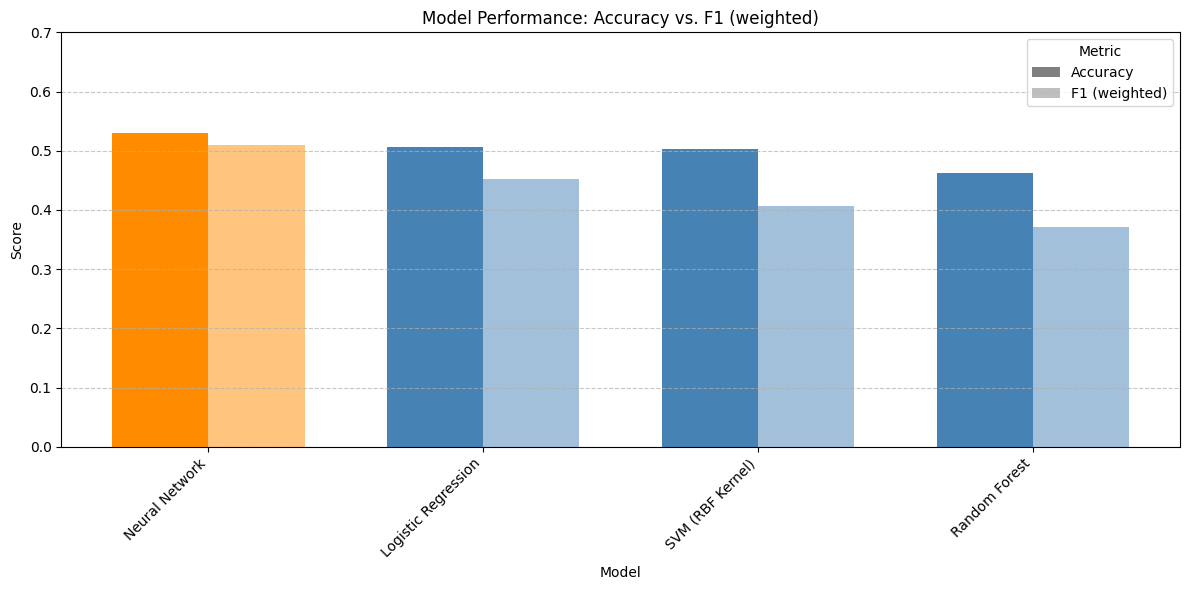

In [135]:
from matplotlib.patches import Patch

# Ensure 'Score' column is numeric for plotting
results_melted['Score'] = results_melted['Score'].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))

# Define default ML color and a distinct color for Neural Network
default_ml_color = 'steelblue'
model_colors = {
    'Neural Network': 'darkorange',
    'Logistic Regression': default_ml_color,
    'SVM (RBF Kernel)': default_ml_color,
    'Random Forest': default_ml_color
}

# Get unique model names and metrics
models = results_melted['Model'].unique()
bar_width = 0.35 # Width of each individual bar
indices = np.arange(len(models)) # X-axis locations for each model group

for i, model_name in enumerate(models):
    model_data = results_melted[results_melted['Model'] == model_name]

    # Plot Accuracy bar
    acc_score = model_data[model_data['Metric'] == 'Accuracy']['Score'].values[0]
    ax.bar(indices[i] - bar_width/2, acc_score, bar_width,
           color=model_colors[model_name], label=f'{model_name} Accuracy')

    # Plot F1 (weighted) bar with reduced alpha for less visibility
    f1_score = model_data[model_data['Metric'] == 'F1 (weighted)']['Score'].values[0]
    ax.bar(indices[i] + bar_width/2, f1_score, bar_width,
           color=model_colors[model_name], alpha=0.5, label=f'{model_name} F1 (weighted)')

# Set plot labels, title, and limits
ax.set_title('Model Performance: Accuracy vs. F1 (weighted)')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 0.7) # Set y-axis limit as requested
ax.set_xticks(indices)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Create a custom legend for Accuracy and F1 (weighted)
legend_handles = [
    Patch(facecolor='gray', label='Accuracy'),
    Patch(facecolor='gray', alpha=0.5, label='F1 (weighted)')
]
ax.legend(handles=legend_handles, loc='upper right', title='Metric')

plt.tight_layout()
plt.show()